In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv('auto-mpg.data', delim_whitespace=True, names=column_names)

# Clean horsepower: replace '?' with NaN and convert to float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

# Map 'origin' to categories
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Asia'})

# One-hot encode origin
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

# Select features (exclude mpg and car_name)
X = df.drop(['mpg', 'car_name'], axis=1)
y = df['mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

C:\Users\meyus\AppData\Local\Temp\ipykernel_12244\2397990008.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('auto-mpg.data', delim_whitespace=True, names=column_names)


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# --- Decision Tree Regression ---
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

# --- Random Forest Regression ---
rf_reg = RandomForestRegressor(random_state=42, n_estimators=100)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper function for evaluation
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Results:")
    print(f"  Mean Absolute Error: {mae:.2f}")
    print(f"  Mean Squared Error: {mse:.2f}")
    print(f"  R² Score: {r2:.2f}")
    print("-" * 40)

# Compare models
evaluate_model("Linear Regression", y_test, y_pred_lin)
evaluate_model("Decision Tree Regression", y_test, y_pred_tree)
evaluate_model("Random Forest Regression", y_test, y_pred_rf)

Linear Regression Results:
  Mean Absolute Error: 2.47
  Mean Squared Error: 10.21
  R² Score: 0.80
----------------------------------------
Decision Tree Regression Results:
  Mean Absolute Error: 2.30
  Mean Squared Error: 11.76
  R² Score: 0.77
----------------------------------------
Random Forest Regression Results:
  Mean Absolute Error: 1.74
  Mean Squared Error: 6.11
  R² Score: 0.88
----------------------------------------


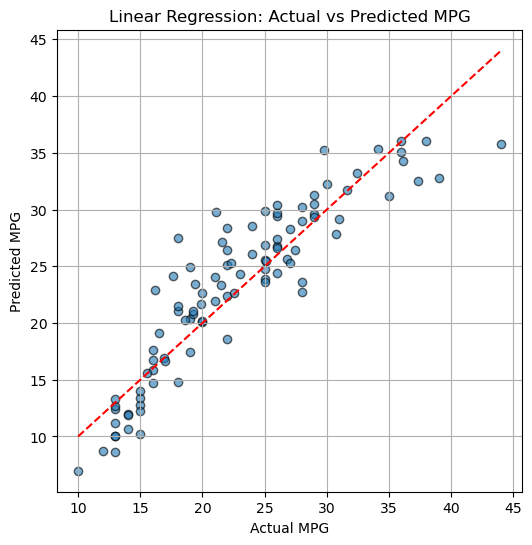

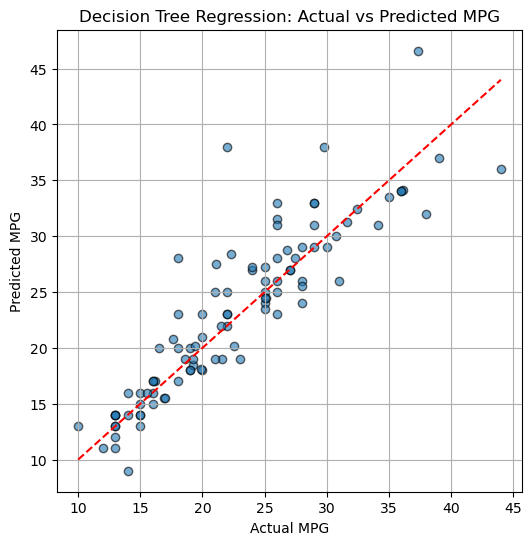

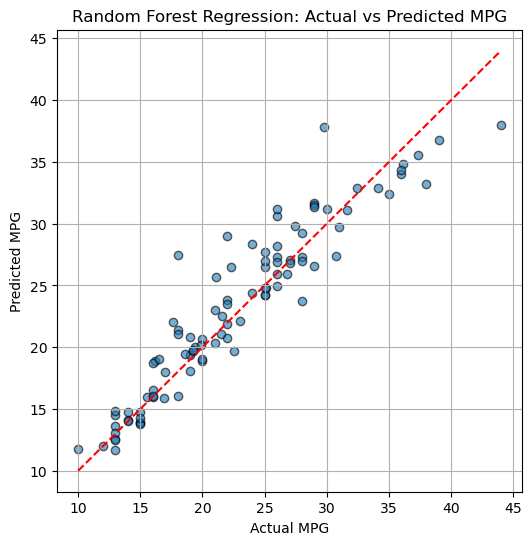

In [5]:
import matplotlib.pyplot as plt

# Function to plot predicted vs actual
def plot_predictions(y_test, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
    plt.xlabel("Actual MPG")
    plt.ylabel("Predicted MPG")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Plot for all three models
plot_predictions(y_test, y_pred_lin, "Linear Regression: Actual vs Predicted MPG")
plot_predictions(y_test, y_pred_tree, "Decision Tree Regression: Actual vs Predicted MPG")
plot_predictions(y_test, y_pred_rf, "Random Forest Regression: Actual vs Predicted MPG")